# Notebook 1: Infrastructure

> This notebook orients you to the AWS resources available in this lab and shows how to move from initial development for error reduction tasks on a Jupyter server to scaled execution on AWS Batch and AWS Parallel Computing Service (PCS).

## 1. AWS Infrastructure

There are two broad computing environments that AWS offer: 
- **Workstation**: a single compute node, which is one machine (physical or virtual) with its own CPUs, RAM, and possibly GPUs. On AWS, the workstation analogue is an `EC2 (Elastic Compute Cloud) instance`, a virtual machine you provision on demand with a chosen number of vCPUs, memory, and accelerators just like this Jupyter Notebook.
- **University cluster (or HPC cluster)**: a pool of many interconnected compute nodes managed by a job scheduler. Researchers submit jobs to a queue; the scheduler allocates nodes and launches the work. This model is familiar from on-premise clusters at universities (e.g., SLURM-managed clusters). AWS offers two managed services that replicate this pattern: `(1) AWS Batch` and `(2) AWS PCS (Parallel Computing Service)`

Our goal for this notebook is to use Amazon computing services on AWS to handled quantum error reduction tasks. Each tasks are demonstrated in the subsequent notebooks of this lab. We will proceed to explain why and how we can integrate the tasks with AWS.

<div align="center">
    
![infrastrure_workflow](figures/infrastructure/aws_workflow_v2.png)

</div>

### Connecting to AWS

Import `boto3` and instantiate a client for each AWS service you will use:


In [1]:
import boto3, time

cfn_client = boto3.client('cloudformation') # CloudFormation
batch_client = boto3.client('batch') # Batch
sts_client = boto3.client("sts") # Security Token Service
s3_client = boto3.client("s3") # Simple Storage Serive
ec2_client = boto3.client('ec2') # Elastic Compute Cloud
ssm_client = boto3.client('ssm') # AWS Systems Manager

Before going further, confirm that your notebook session has valid AWS credentials. The cell below prints your **Account ID** and the **region** your session is operating in.


In [2]:
ACCOUNT_ID = sts_client.get_caller_identity().get("Account")
print("Account ID:", ACCOUNT_ID)

my_session = boto3.session.Session()
WORKING_REGION = my_session.region_name
print("Region:", WORKING_REGION)

# You can switch working region of a service as follow:
# service_client = boto3.client('service', region_name='WORKING_REGION')

Account ID: 338348453266
Region: us-east-1


> Now that we have connected to AWS, let's see how we can implement different computing services into the different workflow of error reduction. 

## 2. Error Reduction Tasks

Each error-reduction technique has a different computational character: hybrid iterative, embarrassingly parallel, or tightly-coupled, which determines the best AWS service. The three subsections below walk through each task and set up the corresponding AWS infrastructure.

### 2.1 Quantum Hardware Noise Suppression

**Noise suppression** encompasses techniques applied *before or during* circuit execution to reduce the impact of hardware noise — for example, dynamical decoupling pulse sequences, optimised gate decompositions, or calibration-aware transpilation. These methods modify the circuits or control pulses sent to the real Quantum Processing Unit (QPU), aiming to suppress decoherence and gate errors at the physical level.

The classical compute requirement is modest (circuit compilation and optimisation), but the workflow is inherently **hybrid**: the classical optimiser must interact with the QPU *iteratively* to calibrate and validate suppression strategies. **AWS Braket Hybrid Jobs** is the natural fit.

> **Notebook 2 activity:** use simulators and QPUs to perform noise suppression on quantum hardware.

#### Setting up Braket

Use `Tracker` to estimate the cost of running circuits on both Amazon Braket Simulators and QPUs before you commit to execution.

In [3]:
from braket.tracking import Tracker

t = Tracker().start()

To run `AWS Braket Hyrbid Jobs`, you will need to connect your Jupyter Notebook to the available AWS Braket hardwares. First, import `braket.devices` and `braket.aws` to access both local simulators and Amazon backend machines.

In [4]:
from braket.devices import Devices, LocalSimulator
from braket.aws import AwsDevice, AwsSession

# You can see the available Amazon Braket simulators by changing "QPU" -> "SIMULATOR"
AwsDevice.get_devices(types=["QPU"])

[Device('name': Aquila, 'arn': arn:aws:braket:us-east-1::device/qpu/quera/Aquila),
 Device('name': Cepheus-1-108Q, 'arn': arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q),
 Device('name': Emerald, 'arn': arn:aws:braket:eu-north-1::device/qpu/iqm/Emerald),
 Device('name': Forte 1, 'arn': arn:aws:braket:us-east-1::device/qpu/ionq/Forte-1),
 Device('name': Forte Enterprise 1, 'arn': arn:aws:braket:us-east-1::device/qpu/ionq/Forte-Enterprise-1),
 Device('name': Garnet, 'arn': arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet),
 Device('name': IBEX Q1, 'arn': arn:aws:braket:eu-north-1::device/qpu/aqt/Ibex-Q1)]

Each result includes an `arn` (Amazon Resource Name) with the format `.../qpu/<hardware-provider>/<device-name>`, which uniquely identifies the backend.

<div class="alert alert-block alert-success">
<b>Activity:</b> From the cell above, pick a QPU and load it below using <code>AwsDevice(Devices.&lt;Provider&gt;.&lt;DeviceName&gt;)</code>. Then check the current queue depth before deciding to submit.
</div>

In [5]:
# load QPU of choice
qpu = AwsDevice(Devices.Rigetti.Cepheus1108Q) # FIX ME

# check for the queue_depth for quantum tasks on the selected device
qpu.queue_depth().quantum_tasks

{<QueueType.NORMAL: 'Normal'>: '10', <QueueType.PRIORITY: 'Priority'>: '0'}

<div class="alert alert-block alert-warning">
<b>Warning:</b> Always estimate QPU cost before running. Charges do not factor in discounts or credits, and EC2 costs may apply on top.
</div>

In [6]:
# If we want to run a circuit with 1000 shots on QPU of choice, how much would it cost?
shots = 1000
per_shot_cost = qpu.properties.service.deviceCost
print(shots * per_shot_cost.price, "USD")

0.425 USD


You can also use the tracker function from before to estimate the cost of running an example

In [7]:
# print(f"Estimated cost to run this example: {t.qpu_tasks_cost() + t.simulator_tasks_cost():.2f} USD",)

### 2.2 Quantum Error Mitigation

**Error mitigation** is a family of post-processing techniques that extract better estimates of noise-free expectation values from noisy measurement data *without* adding extra qubits. Examples include zero-noise extrapolation (ZNE), probabilistic error cancellation (PEC), and Clifford data regression (CDR).

A common pattern is: run many **circuit variants** (e.g., at different noise scale factors), collect measurement statistics, and combine them classically. Each variant is completely independent (i.e., no inter-job communication is needed) making this workload **embarrassingly parallel** and a natural fit for **AWS Batch**.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("inputs/aws/batch_scaling_results.json", "r") as f:
    results = json.load(f)

T_overhead = np.array(results["T_OVERHEAD"]) # batch overhead time
T_serial = np.array(results["T_serial"])  # zero_noise_extrapolation timestep for loop runtime
T_batch  = np.array(results["T_batch"])   # per-step batch time
steps    = np.arange(1, len(T_serial) + 1)

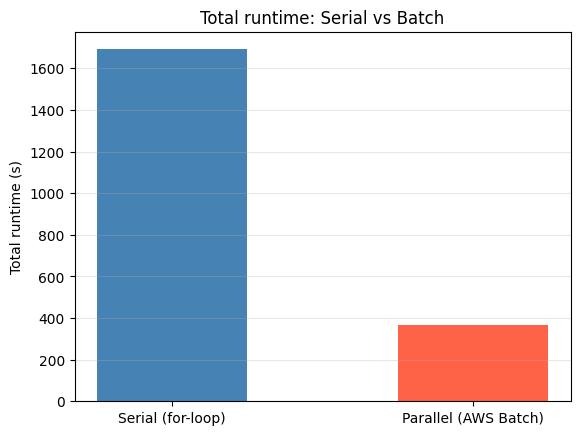

In [10]:
total_serial = np.sum(T_serial)
total_batch  = T_overhead + np.max(T_batch)

labels = ["Serial (for-loop)", "Parallel (AWS Batch)"]
values = [total_serial, total_batch]
colors = ["steelblue", "tomato"]

plt.bar(labels, values, color=colors, width=0.5)
# plt.bar_label(bars, fmt="%.2f s", padding=3)
plt.ylabel("Total runtime (s)")
plt.title("Total runtime: Serial vs Batch")
plt.grid(True, axis="y", alpha=0.3) 
plt.show()

#### Setting up AWS Batch for Error Mitigation

Deploying AWS Batch requires two CloudFormation YAML files:
- `inputs/aws/basic-infrastructure.yaml` — VPC, subnets, IAM roles
- `inputs/aws/batch-environment.yaml` — Batch compute environment, job queue, and job definition

The cell below creates (or updates) the CloudFormation stack and prints the key output values you will need in subsequent steps.


In [12]:
with open('inputs/aws/batch-environment.yaml', 'r') as file:
    template_body = file.read()

stack_name = 'project-batch-environment' # change as needed

try:
    print(f"Creating CloudFormation stack {stack_name}")
    cfn_client.create_stack(
        StackName=stack_name,
        TemplateBody=template_body,
    )
    print("Waiting for CloudFormation stack to complete...")
    waiter = cfn_client.get_waiter("stack_create_complete")
    waiter.wait(
        StackName=stack_name,
        WaiterConfig={'Delay': 10, 'MaxAttempts': 150}
    )
    print("CloudFormation stack completed.")
except cfn_client.exceptions.AlreadyExistsException:
    print("Stack already exists. Updating CloudFormation stack")
    try:
        cfn_client.update_stack(
            StackName=stack_name,
            TemplateBody=template_body,
        )
        print("Waiting for CloudFormation stack to be updated...")
        waiter = cfn_client.get_waiter("stack_update_complete")
        waiter.wait(
            StackName=stack_name,
            WaiterConfig={'Delay': 10, 'MaxAttempts': 150}
        )
        print("CloudFormation stack updated.")
    except cfn_client.exceptions.ClientError as e:
        print(e)

print()
for output in cfn_client.describe_stacks(StackName=stack_name).get('Stacks')[0].get('Outputs'):
    print(f"{output.get('OutputKey')}: {output.get('OutputValue')}")

Creating CloudFormation stack project-batch-environment
Stack already exists. Updating CloudFormation stack
An error occurred (ValidationError) when calling the UpdateStack operation: No updates are to be performed.

DataBucketName: amazon-braket-batch-project-338348453266-us-east-1
BatchImageRepositoryUri: 338348453266.dkr.ecr.us-east-1.amazonaws.com/amazon-braket-batch-project-batch
LambdaImageRepositoryUri: 338348453266.dkr.ecr.us-east-1.amazonaws.com/amazon-braket-batch-project-lambda
JobQueue: arn:aws:batch:us-east-1:338348453266:job-queue/BatchJobQueue-DwK2eKqogDQRvc5J
JobDefinition: arn:aws:batch:us-east-1:338348453266:job-definition/BatchJobDefinition-hdbHwiKa55wylaV8:1


<div class="alert alert-block alert-success">
<b>Activity:</b> Copy the values printed above into the cell below. These identifiers are used by all subsequent Batch job submissions.
</div>


In [13]:
data_bucket_name = "amazon-braket-batch-project-338348453266-us-east-1"  # FIXME
batch_image_repository_uri = "338348453266.dkr.ecr.us-east-1.amazonaws.com/amazon-braket-batch-project-batch"  # FIXME
job_queue = "arn:aws:batch:us-east-1:338348453266:job-queue/BatchJobQueue-DwK2eKqogDQRvc5J"  # FIXME
job_definition = "arn:aws:batch:us-east-1:338348453266:job-definition/BatchJobDefinition-hdbHwiKa55wylaV8:1"  # FIXME

#### Build and push the Docker container image

AWS Batch runs your code inside a Docker container. The cell below:
1. Authenticates your local Docker daemon to your ECR private registry
2. Builds the image for the `linux/amd64` platform (required for Batch)
3. Pushes the image to ECR so Batch workers can pull it

In [14]:
%%time
import os

print("Authenticating Docker to your Amazon ECR private registry...")
os.system(f"aws ecr get-login-password --region {WORKING_REGION} | docker login --username AWS --password-stdin {ACCOUNT_ID}.dkr.ecr.{WORKING_REGION}.amazonaws.com")

print("Building your Docker image locally...")
os.system(f"docker build --quiet --platform linux/amd64 -f batch_container_image/Dockerfile -t {batch_image_repository_uri} .")

print("Pushing your Docker image to your ECR repository...")
os.system(f"docker push --quiet {batch_image_repository_uri}")

print("All done.")

Authenticating Docker to your Amazon ECR private registry...


WARNING! Your password will be stored unencrypted in /home/ec2-user/.docker/config.json.
Configure a credential helper to remove this warning. See
https://docs.docker.com/engine/reference/commandline/login/#credentials-store



Login Succeeded
Building your Docker image locally...
sha256:4a6efb0fa4fb01305c97e61cd7ddd66f1d0251dbf48e3755025156221ae2c908
Pushing your Docker image to your ECR repository...
338348453266.dkr.ecr.us-east-1.amazonaws.com/amazon-braket-batch-project-batch:latest
All done.
CPU times: user 5.64 ms, sys: 851 μs, total: 6.49 ms
Wall time: 2.63 s


> **Notebook 3 activity:** play around with different values of error mitigation code and compare runtime in for-loop vs. sending the jobs through Batch.


### 2.3 Quantum Error Correction (Shor Code)

**Quantum error correction (QEC)** encodes logical qubits into many physical qubits and actively detects and corrects errors via syndrome measurements. The **Shor code** (the 9-qubit code) is the first QEC code, encoding one logical qubit into 9 physical qubits via a concatenation of bit-flip and phase-flip repetition codes.

Simulating QEC for decoding, logical error rate estimation, and threshold studies is computationally demanding: the state-vector or density matrix grows **exponentially** with qubit count, and processes on different nodes must exchange boundary information during simulation. This is a **tightly-coupled** workload, which is why we use **AWS PCS** rather than AWS Batch.

> **Notebook 4 activity:** explore Shor's code for error correction and how this scaling motivates moving to surface codes.


#### Accessing the HPC cluster key pair

AWS PCS nodes are accessed over SSH. The key pair is stored securely in AWS Systems Manager Parameter Store and retrieved below.


In [15]:
key_pair_id = ec2_client.describe_key_pairs(Filters=[{'Name': 'key-name','Values': ['hpc-key-pair']}]).get('KeyPairs')[0].get('KeyPairId')
print(key_pair_id)

key-02776ff31e6e224c8


In [16]:
import os, stat

filename = "private/hpc-key-pair.pem"
parameter_name = f"/ec2/keypair/{key_pair_id}" 
key = ssm_client.get_parameter(Name=parameter_name, WithDecryption=True).get('Parameter').get('Value')
with open(filename, "x") as f: 
    f.write(key) 
os.chmod(filename, stat.S_IREAD)

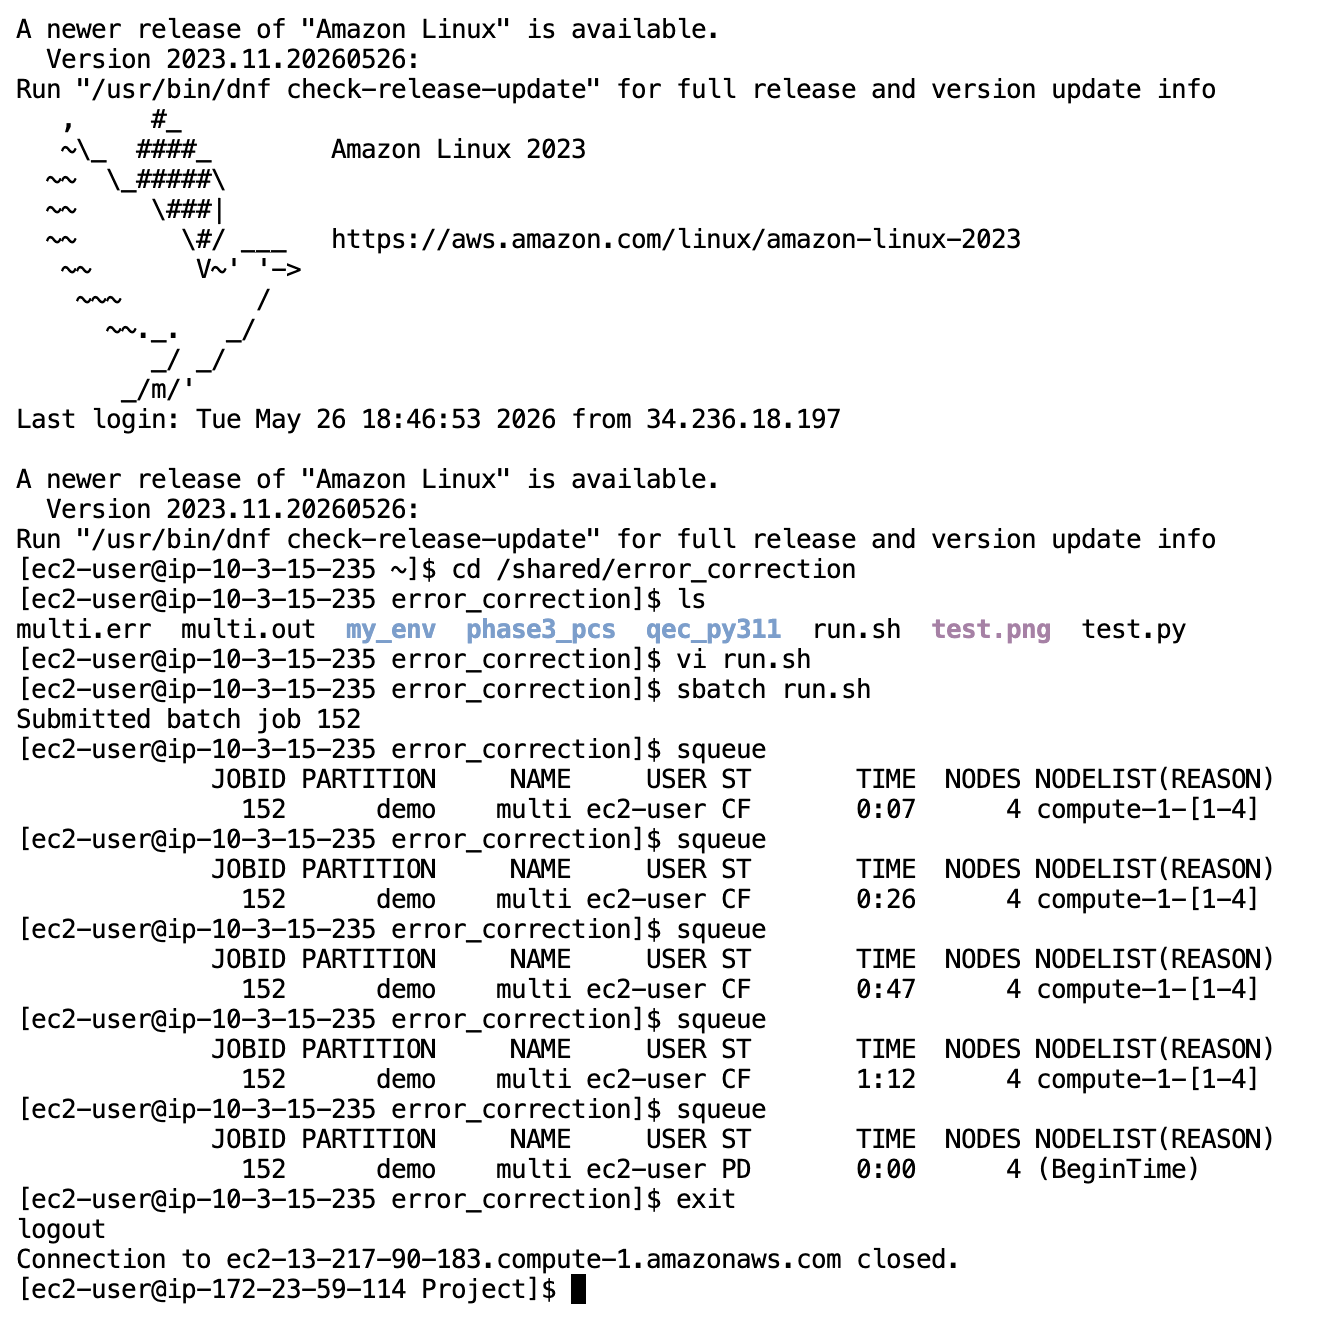

#### Using PCS from the terminal

The first thing you need to do to access PCS on the terminal is to locate your `EC2's public IPv4 DNS`. You can do this from the AWS Comsole by looking up EC2 like below:
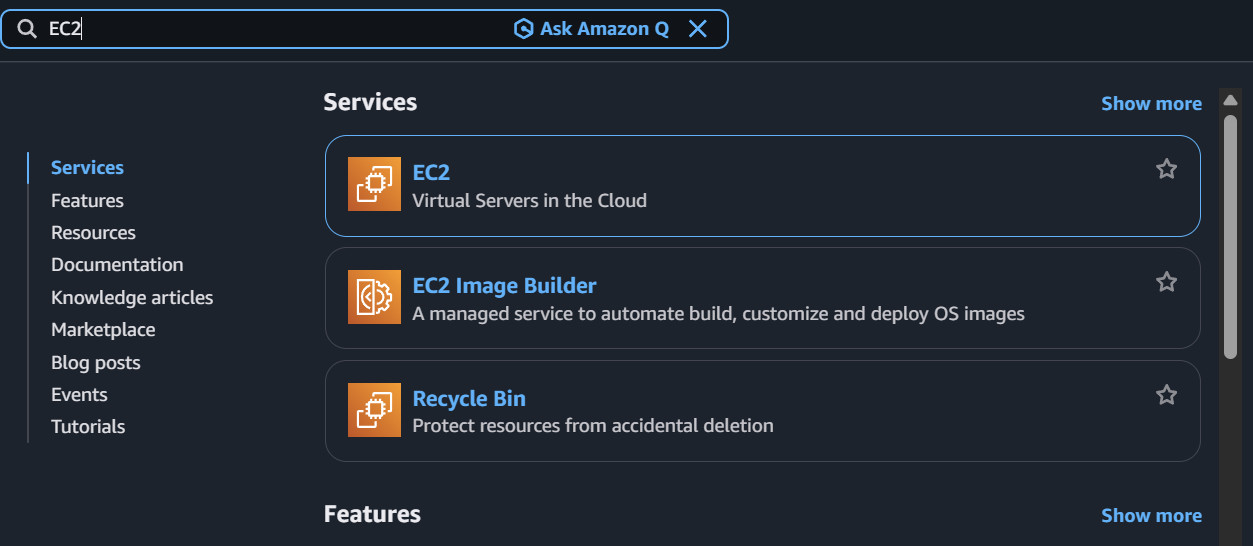

Next, choose `Instances`: 

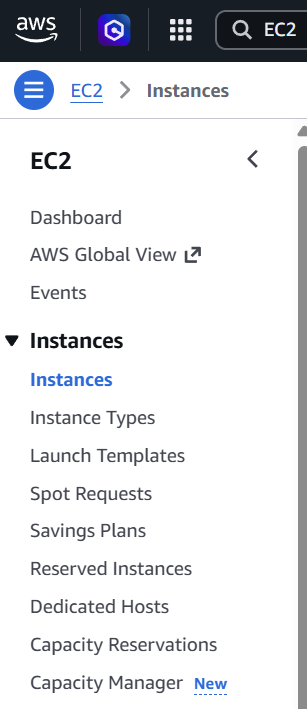

The public IPv4 DNS, or we would refer to in our workflow below as `<head-node-public-dns>` is displayed on the selected instance 
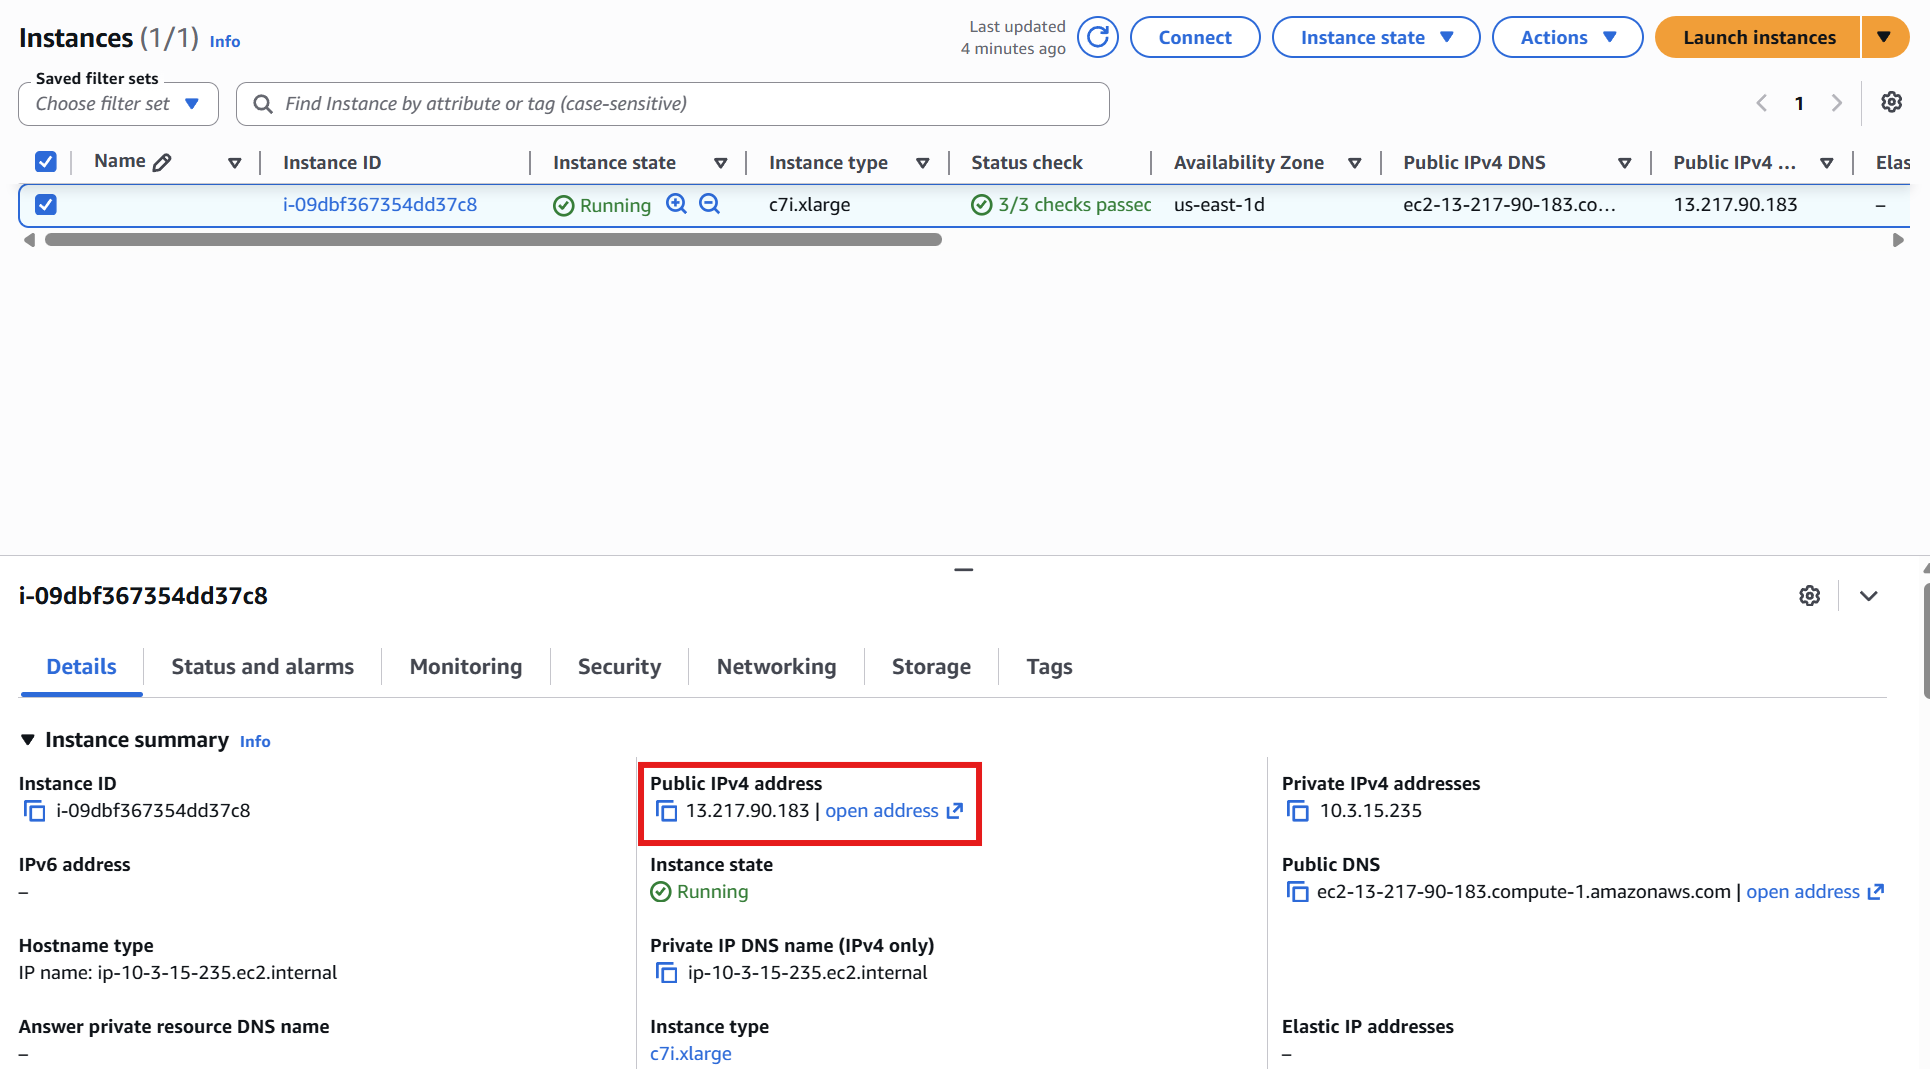

Importantly, we need to upload `surface_code` folder to the PCS computer node using the following command on the terminal: 

```bash
scp -i "private/hpc-key-pair.pem" -r "Surface code/surface_code" ec2-user@<head-node-public-dns>/shared/
```

Once the key is saved, all interaction with the cluster happens over SSH. The workflow is:

**1. SSH into the head node.**  
The head node is the entry point to the cluster — it runs the SLURM scheduler and has access to the shared filesystem. Replace the hostname with the value printed by `ec2_client.describe_instances` or from the EC2 console.

```bash
ssh -i "private/hpc-key-pair.pem" ec2-user@<head-node-public-dns>
```

**2. Navigate to the shared working directory.**  
Everything under `/shared` is visible on every compute node. The error-correction scripts and results should live here.

```bash
cd /shared/error_correction
```

**3. Submit a job with `sbatch`.**  
SLURM jobs are described in a shell script with `#SBATCH` directives. Submit it with:

```bash
sbatch submit_shor.sh
# → Submitted batch job 42
```

**4. Monitor the queue.**  
Check the status of your job and all others running on the cluster:

```bash
squeue --me          # show only your jobs
sacct -j 42 --format=JobID,Elapsed,CPUTime,State   # accounting after completion
```

**5. Copy results back to this Jupyter server.**  
Once the job is complete, use `scp` to pull the output files from `/shared` back to the notebook environment:

```bash
scp -i "private/hpc-key-pair.pem" \
  ec2-user@<head-node-public-dns>:/shared/surface_code/results/ .
```